In [1]:
using Oceananigans, CairoMakie
using ColorSchemes
using MPI

┌ Info: Oceananigans will use 8 threads
└ @ Oceananigans /nfs/stak/users/carlipp/.julia/packages/Oceananigans/mLrHQ/src/Oceananigans.jl:137


In [2]:
loc = "/nfs/hpc/share/carlipp/ngpu-scaling/"
ds_1gpu = FieldDataset(loc*"1gpu_data_rank0.jld2"; backend = OnDisk())
ds_2gpu = FieldDataset(loc*"2gpu_data_rank0.jld2"; backend = OnDisk())
ds_4gpu = FieldDataset(loc*"4gpu_data_rank0.jld2"; backend = OnDisk())

FieldDataset with 5 fields and 0 metadata entries:
├── KE: 1×1×1×21 FieldTimeSeries{OnDisk} located at (⋅, ⋅, ⋅) of KE at /nfs/hpc/share/carlipp/ngpu-scaling/4gpu_data_rank0.jld2
├── dissipation: 1×1×1×21 FieldTimeSeries{OnDisk} located at (⋅, ⋅, ⋅) of dissipation at /nfs/hpc/share/carlipp/ngpu-scaling/4gpu_data_rank0.jld2
├── u: 256×1024×512×21 FieldTimeSeries{OnDisk} located at (Face, Center, Center) of u at /nfs/hpc/share/carlipp/ngpu-scaling/4gpu_data_rank0.jld2
├── v: 256×1024×512×21 FieldTimeSeries{OnDisk} located at (Center, Face, Center) of v at /nfs/hpc/share/carlipp/ngpu-scaling/4gpu_data_rank0.jld2
└── w: 256×1024×512×21 FieldTimeSeries{OnDisk} located at (Center, Center, Face) of w at /nfs/hpc/share/carlipp/ngpu-scaling/4gpu_data_rank0.jld2


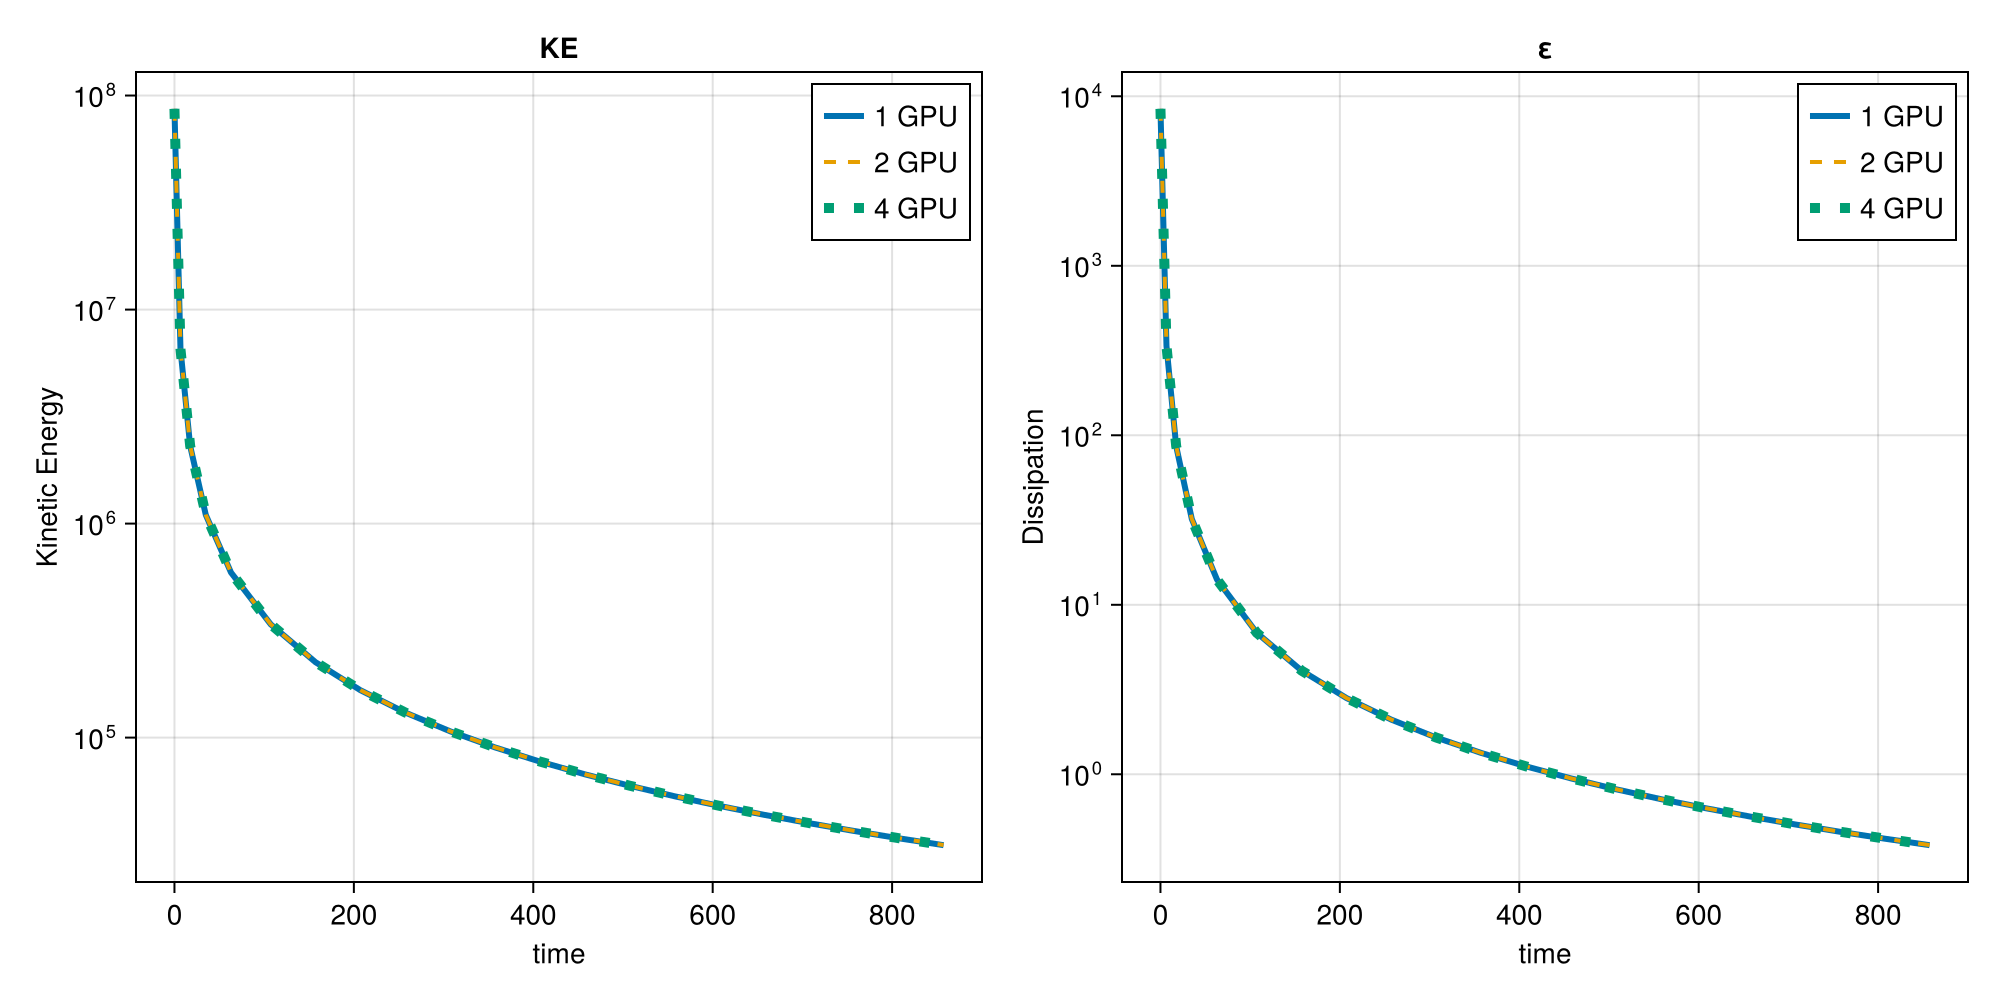

In [3]:
fig = Figure(size = (1000, 500))
ax = Axis(fig[1, 1], yscale = log10, title = "KE", ylabel = "Kinetic Energy", xlabel = "time")
ax2 = Axis(fig[1, 2], yscale = log10, title = "ε", ylabel = "Dissipation", xlabel = "time")
lines!(ax, ds_1gpu.KE, label = "1 GPU", linewidth = 3)
lines!(ax, ds_2gpu.KE, label = "2 GPU", linestyle = :dash, linewidth = 2)
lines!(ax, ds_4gpu.KE, label = "4 GPU", linestyle = :dot, linewidth = 5)
lines!(ax2, ds_1gpu.dissipation, label = "1 GPU", linewidth = 3)
lines!(ax2, ds_2gpu.dissipation, label = "2 GPU", linestyle = :dash, linewidth = 2)
lines!(ax2, ds_4gpu.dissipation, label = "4 GPU", linestyle = :dot, linewidth = 5)
axislegend(ax)
axislegend(ax2)
fig

In [4]:
println([collect(ds_1gpu.KE[i])[1] for i = 1:21])
println([collect(ds_2gpu.KE[i])[1] for i = 1:21])
println([collect(ds_4gpu.KE[i])[1] for i = 1:21])

Float32[8.669723f7, 6.520324f6, 2.3020385f6, 1.0976942f6, 591213.44, 338229.1, 224966.52, 166493.27, 130897.8, 107039.586, 89998.51, 77258.66, 67403.48, 59575.77, 53223.73, 47977.285, 43578.71, 39844.473, 36639.695, 33863.125, 31437.31]
Float32[8.669612f7, 6.5206775f6, 2.3021405f6, 1.0977629f6, 591328.0, 338366.84, 225110.69, 166634.0, 131027.09, 107154.27, 90098.85, 77348.12, 67486.19, 59652.086, 53294.6, 48043.543, 43641.125, 39903.246, 36694.434, 33913.688, 31483.83]
Float32[8.66998f7, 6.5209435f6, 2.3021495f6, 1.0977371f6, 591264.56, 338272.03, 225029.25, 166579.67, 130987.54, 107123.945, 90074.08, 77327.3, 67467.08, 59633.504, 53275.805, 48024.082, 43620.992, 39882.76, 36674.145, 33893.914, 31464.629]
